### Importação das bibliotecas e carregamento do dataset

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [3]:
df = pd.read_csv('E Commerce Dataset.csv')

# Análise exploratória dos dados

Visualização de uma amostra inicial do dataset

In [4]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


Visualização de informações sobre o dataset

In [5]:
# o número de linhas e colunas do dataset
print(df.shape, '\n')

# tipos de colunas e quantidade de valores não nulos
print(df.info(), '\n')

# sumário estatístico descritivo do dataset
print(df.describe(), '\n')

# quantidade de valores nulos em cada coluna
print(df.isna().sum(), '\n')

# quantos valores de cada tem na coluna target
print(df['Churn'].value_counts())

(5630, 20) 

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress 

In [6]:
df['Churn'].head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

Verifiquei os valores de algumas features que fiquei em dúvida na interpretação para ver quais eram categoricas (0,1) e quais eram numéricas para me ajudar a intepretalas corretamente

In [7]:
print(df['SatisfactionScore'].unique())
print(df['Complain'].unique())
print(df['HourSpendOnApp'].unique())
print(df['CouponUsed'].unique())

[2 3 5 4 1]
[1 0]
[ 3.  2. nan  1.  0.  4.  5.]
[ 1.  0.  4.  2.  9.  6. 11. nan  7. 12. 10.  5.  3. 13. 15.  8. 14. 16.]


# Visualização gráfica dos dados

Verifiquei o balanceamento do target utilizando um gráfico de contagem

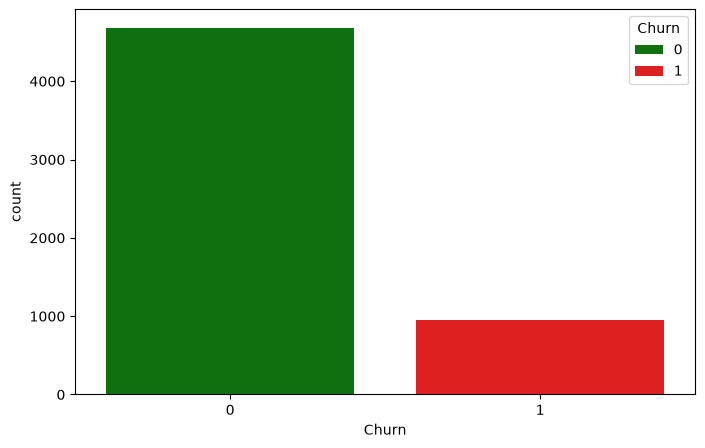

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(df, x='Churn', hue='Churn', palette=['green', 'red'])
plt.show()

Verifiquei a média de cupons utilizados por cada grupo

Objetivo: Validar se o uso de cupons de desconto realmente ajuda a impedir do cliente cancelar o serviço

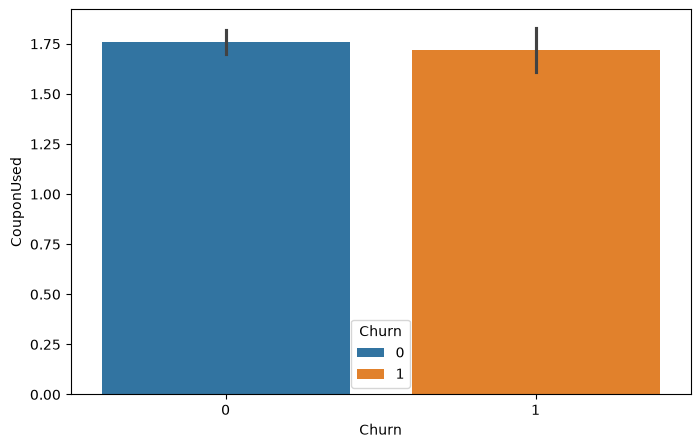

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Churn', y='CouponUsed', hue='Churn')
plt.show()

Verifiquei a distribuição das nivel de satisfação dos clientes

Objetivo: obter algum insight

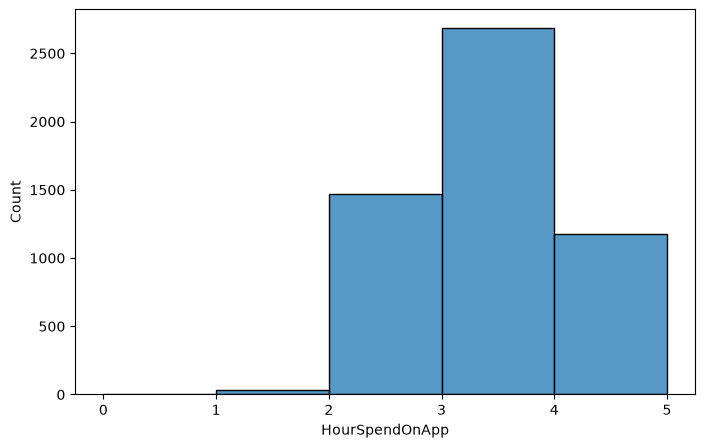

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='HourSpendOnApp', bins=5)
plt.show()

Verifiquei a distribuição da distancia do armazém até a casa dos clientes

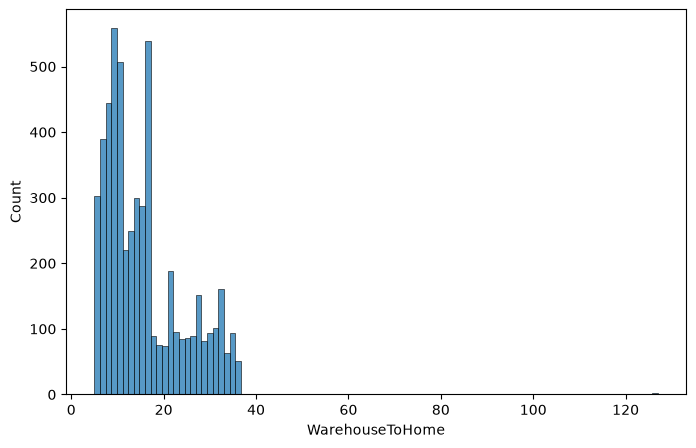

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='WarehouseToHome', bins=100)
plt.show()

No gráfico acima notei que havia um valor extremamente distante dos outros, então decidi plotar um gráfico de caixa para verificar se era um outlier

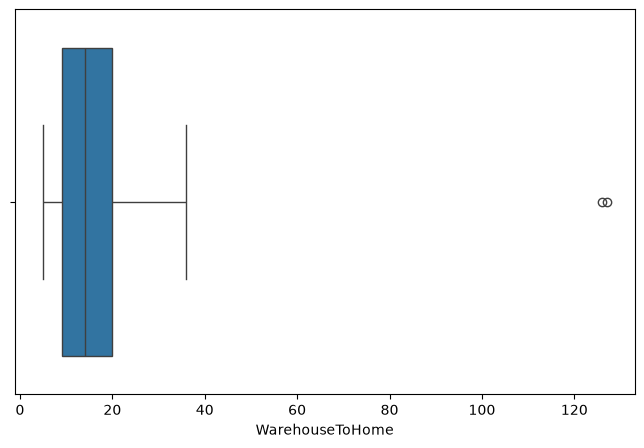

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='WarehouseToHome')
plt.show()

taxa de reclamações entre os grupos que cancelaram e não cancelaram o serviço

Objetivo: verificar se reclamações é um fator relevante para o cliente deixar de assinar o serviço

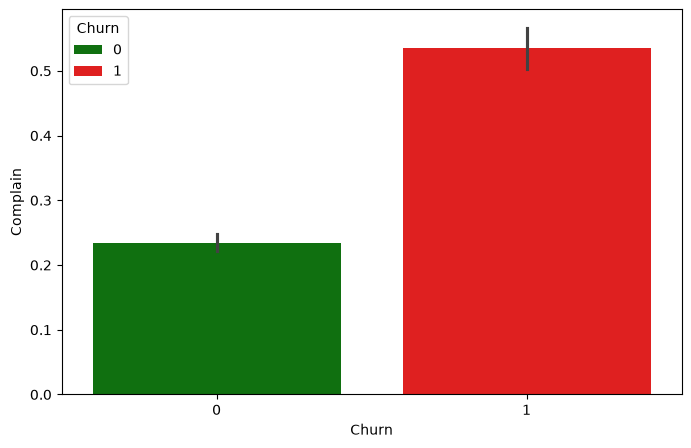

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='Complain', hue='Churn', palette=['green', 'red'])
plt.show()

nivel de satisfação entre os grupos

Objetivo: Verificar se o nível de satisfação é um fator relevante para o cancelamento do serviço

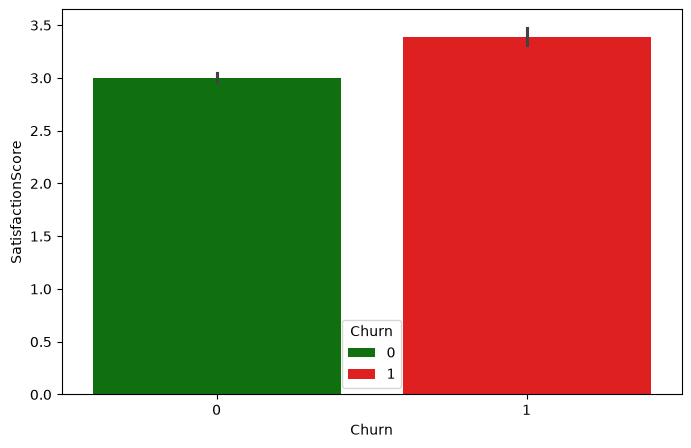

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='SatisfactionScore', hue='Churn', palette=['Green', 'Red'])
plt.show()

a distancia média entre o armazém e o cliente dos grupos que reclamaram e dos grupos que cancelaram o serviço

o objetivo desse gráfico foi testar minha hipótese de que os clientes que moram mais longe do armazem acabam tendo mais reclamações e por conta disso acabam deixando o serviço

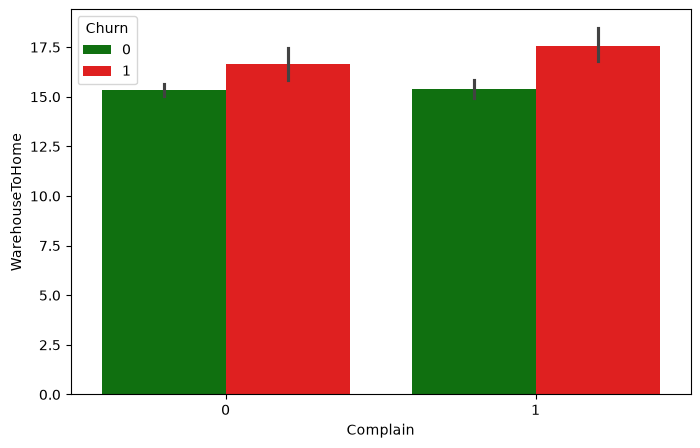

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Complain', y='WarehouseToHome', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verifiquei a quantidade média de pedidos entre os clientes que cancelaram ou não o serviço

Objetivo: testar minha hipótese de que os clientes que cancelaram o serviço foram os que mais compraram dentro da plataforma antes de cancelar o serviço

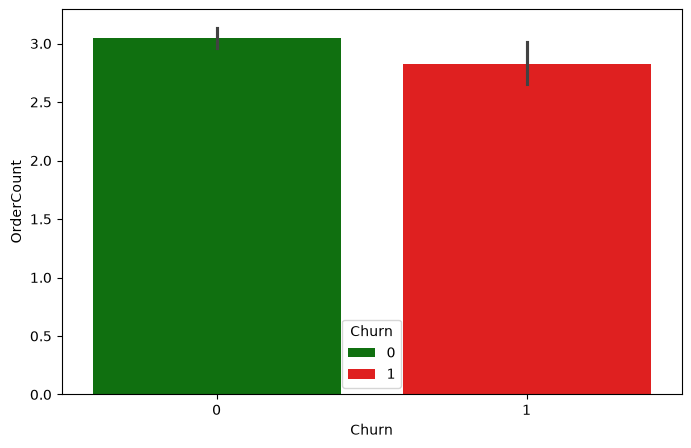

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='OrderCount', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verificar a correlação entre Distancia do cliente, quantidade de pedidos e o cancelamento do serviço

Objetivo: testar a hipótese de que existe a distância do cliente afeta a quantidade de pedidos que ele faz e consequentemente afeta a decisão dele de cancelar o serviço

[]

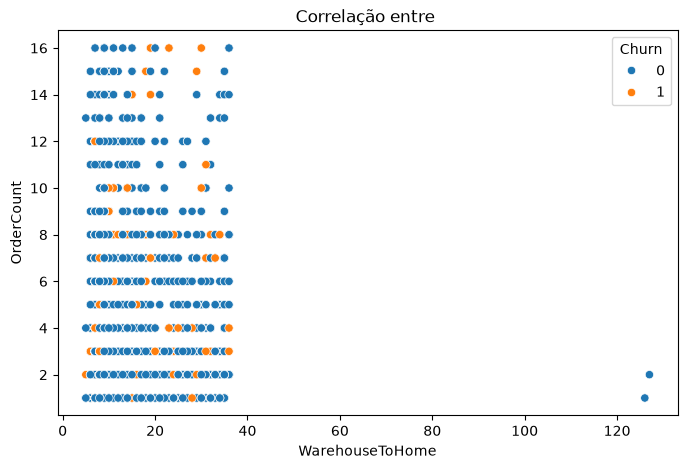

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='WarehouseToHome', y='OrderCount', hue='Churn')
plt.title('Correlação entre ')
plt.plot()

Fiz uma matriz de correlação das variaveis numéricas para verificar e validar as correlações reais das variaveis

Objetivo: Validar as correlações e não correlações que identifiquei nos gráficos anteriores e ver outras correlações que eu posso não ter percebido

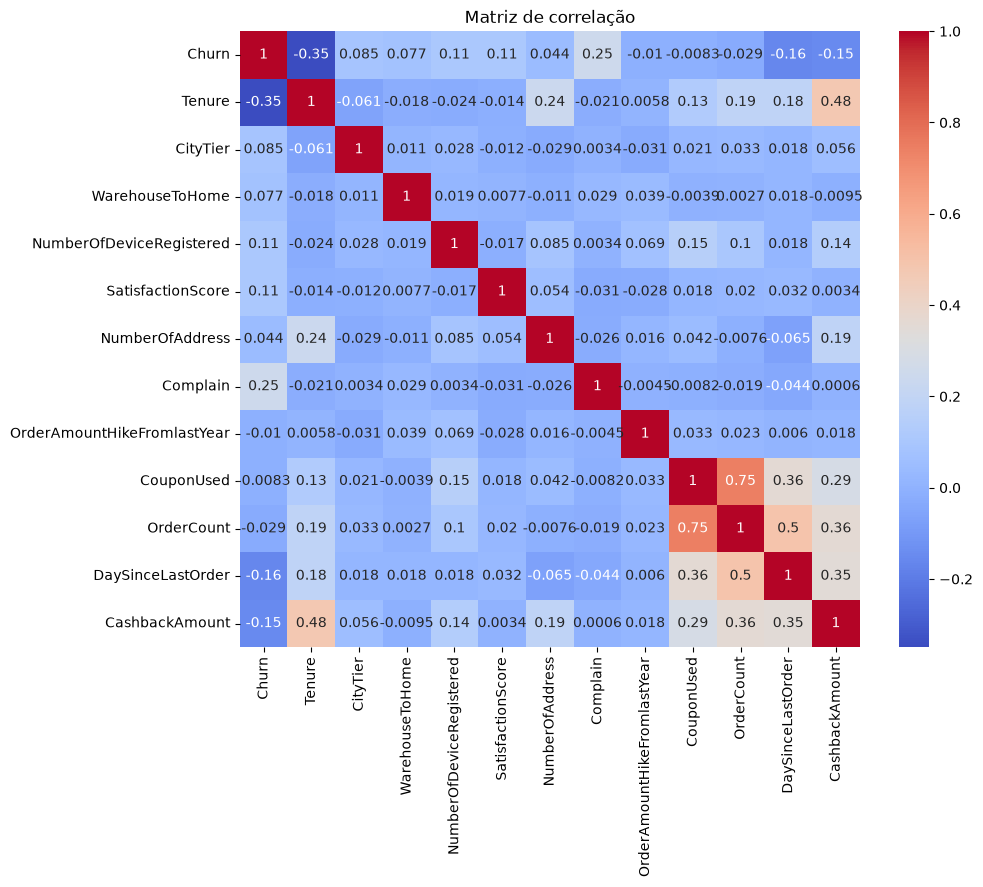

In [18]:
df_numeric = df[['Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
                'NumberOfDeviceRegistered', 'SatisfactionScore',
                'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']]

df_corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(data=df_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

### Insights

A base esta extremamente desbalanceada quanto ao target, a maior parte dos dados são de clientes que não cancelaram o serviço e isso é um problema pois o que precisamos prever são os clientes que vão cancelar o serviço, então vou precisar aplicar técnicas de balanceamento para o modelo ter 50/50 dos 2 casos.
Os cupons não são um fator relevante para retenção dos clientes, isso é importante pois talvez distribuir cupons de descontos não seja a melhor estratégia para reter clientes no serviço.
O maior fator que faz os clientes cancelarem o serviço são as reclamações, clientes que reclamam tem uma tendência muito maior, praticamente o dobro de chance de cancelarem o serviço do que os clientes que não tiveram nenhuma reclamação
e o maior fator para retenção do cliente é o tempo de permanência no serviço (Tenure) na empresa, e este fator é influenciado pela quantidade de cashback que também ifluência o churn como mostrado na matriz de correlação. Talvez utilizar o cashback seja uma estratégia melhor de retenção ao cliente do que cupons de desconto.

# Preparação dos dados (Data Prep)

### Exclui registros duplicados duplicados

In [19]:
# Remove a coluna ID do dataset para não afetar a detecção de duplicadas
df_duplicate = df.drop(columns=['CustomerID'])
df_duplicate.drop_duplicates()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.0,Computer,1,12.0,Credit Card,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,NaN,224
5624,0,1.0,Mobile Phone,3,12.0,UPI,Female,2.0,5,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,155
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186


### Checa o número de registros nulos de cada coluna

In [20]:
df_na = df_duplicate.copy()
df_na.isna().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

### Utiliza histograma e boxplot para identificar a distribuição dos valore nos campos

O Histograma foi utilizado para ter a visualização geral do padrão da distribuição, o boxplot foi utilizado identificar se nos campos haviam outliers que poderiam atrapalhar o calculo da média e para me auxiliar a identificar e confirmar o padrão geométrico identificado no diagrama

O Objetivo dessa etapa é auxiliar a decidir quais campos numéricos eu preencherei com média e mediana

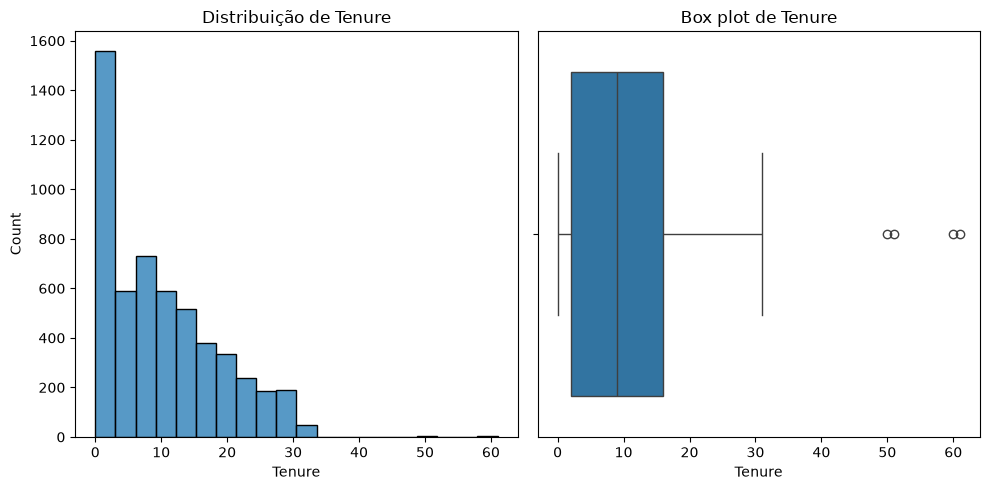

Tenure 
Média: 10.189899366380917 
Mediana: 9.0


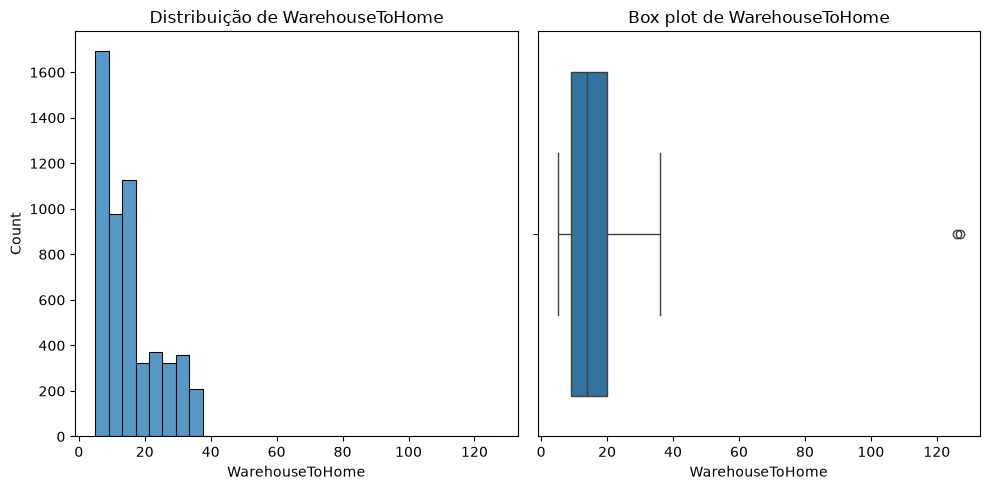

WarehouseToHome 
Média: 15.639895891429633 
Mediana: 14.0


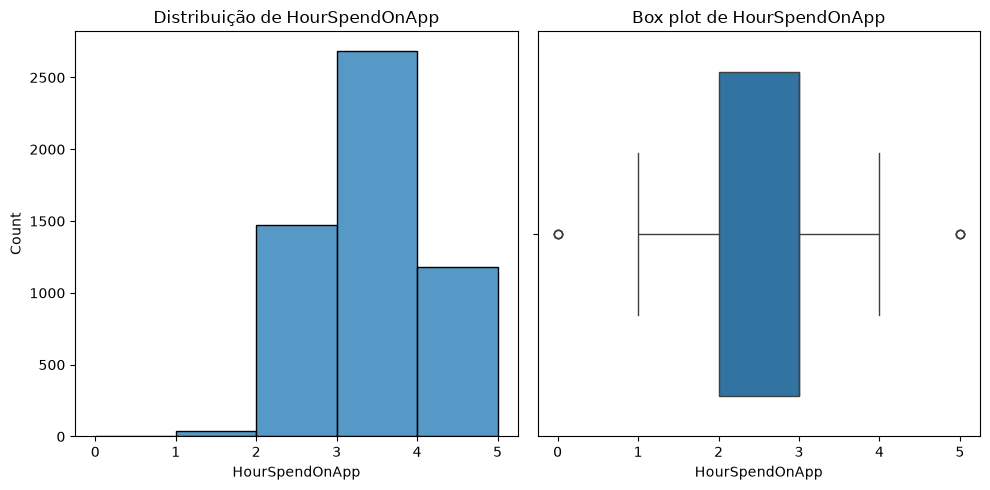

HourSpendOnApp 
Média: 2.9315348837209303 
Mediana: 3.0


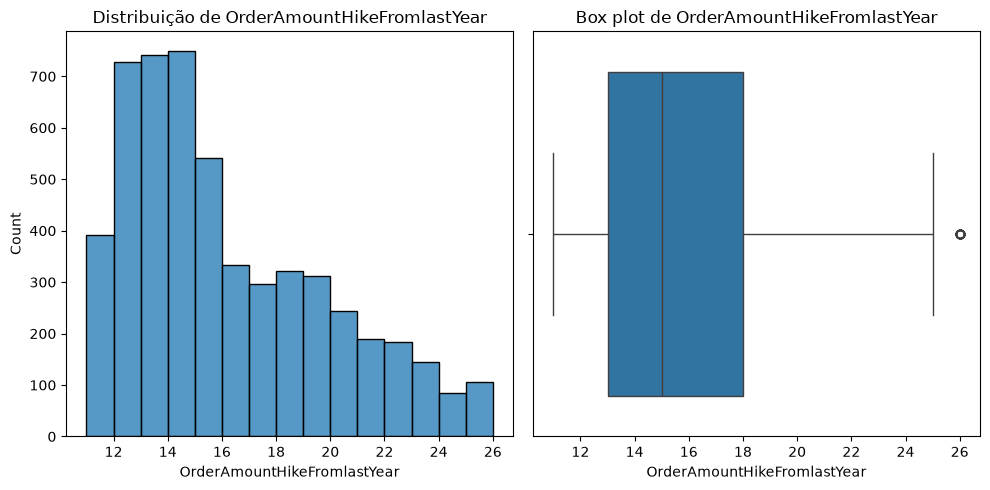

OrderAmountHikeFromlastYear 
Média: 15.707921714818266 
Mediana: 15.0


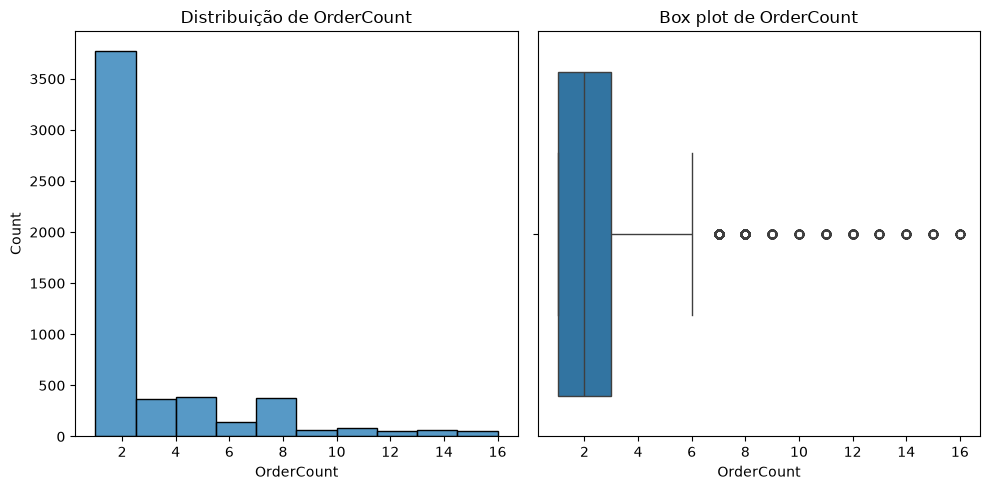

OrderCount 
Média: 3.0080044676098288 
Mediana: 2.0


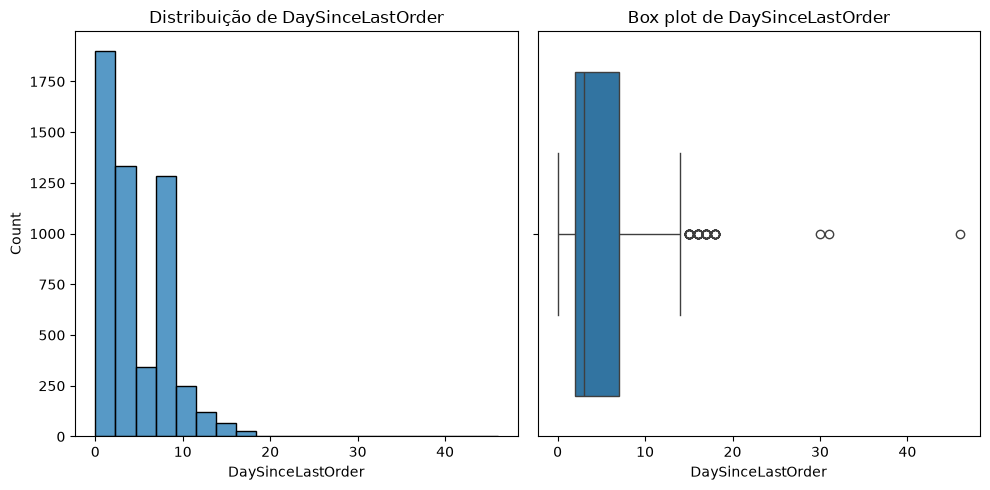

DaySinceLastOrder 
Média: 4.543490512868683 
Mediana: 3.0


In [21]:
columns_numeric = [('Tenure', 20), ('WarehouseToHome', 30), ('HourSpendOnApp', 5), ('OrderAmountHikeFromlastYear', 15),
                    ('OrderCount', 10), ('DaySinceLastOrder', 20)]

for c in columns_numeric:
    fig, axes = plt.subplots(1,2, figsize=(10,5))

    sns.histplot(data=df_na, x=c[0], bins=c[1], ax=axes[0])
    axes[0].set_title(f'Distribuição de {c[0]}')

    sns.boxplot(data=df_na, x=c[0], ax=axes[1])
    axes[1].set_title(f'Box plot de {c[0]}')

    plt.tight_layout()
    plt.show()

    print(f'{c[0]} \nMédia: {df[c[0]].mean()} \nMediana: {df[c[0]].median()}')

Após a geração dos gráficos eu decidi que iria preencher as seguintes colunas com mediana: Tenure, WarehouseToHome, OrderAmountHikeFromlastYear, OrderCount e DaySinceLastOrder, pois no histograma foi identificado uma distribuição assimétrica e no boxplot foi identificados outliers que destorceram a média

O campo que eu decidi preencher com a média foi o HourSpendOnApp, pois o histograma seguia uma distribuição simétrica e os outliers identificados no boxplot são valores coerentes e que não atrapalham o calculo da média

### Preenche os campos com média e mediana

In [22]:
columns_median = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear', 'OrderCount', 'DaySinceLastOrder']

for c in columns_median:
    df_na[c] = df_na[c].fillna(df[c].median())

df_na['HourSpendOnApp'] = df_na['HourSpendOnApp'].fillna(df_na['HourSpendOnApp'].mean())

### Deleta registros nulos

As colunas que sobraram eram colunas categoricas que não fariam sentido preencher com média ou mediana, mas em um cenário real seria válido consultar o setor responsavel pela origem dos dados para tentar preencher o máximo de dados nulos

In [23]:
df_drop = df_na.copy()
df_drop = df_drop.dropna()

### Detecção de outliers

Foi gerado gráficos boxplot de todos as colunas numéricas para indentificar outliers.
Também foi gerado abaixo de cada gráfico um mini relatório contendo o nome do campo, limite inferior, limite superior, número de outliers e a porcentagem que a quantidade desses outliers representam no dataset inteiro

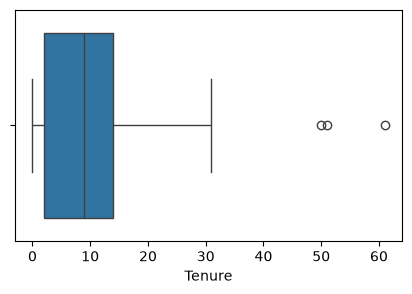

Tenure
Limite Inferior: 0
Limite Superior: 32.0
Número de ouliers: 3
Porcentagem de outliers: 0.06%


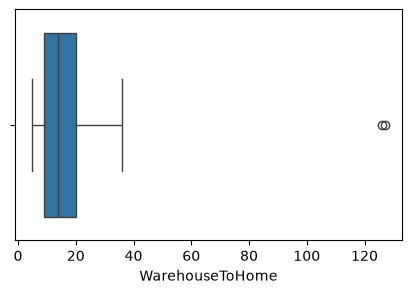

WarehouseToHome
Limite Inferior: 0
Limite Superior: 36.5
Número de ouliers: 2
Porcentagem de outliers: 0.04%


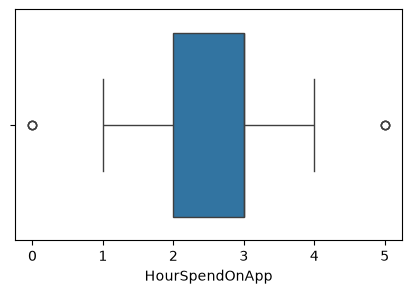

HourSpendOnApp
Limite Inferior: 0.5
Limite Superior: 4.5
Número de ouliers: 6
Porcentagem de outliers: 0.11%


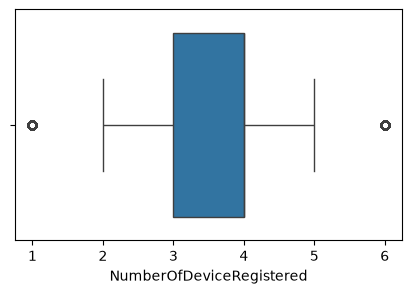

NumberOfDeviceRegistered
Limite Inferior: 1.5
Limite Superior: 5.5
Número de ouliers: 385
Porcentagem de outliers: 7.16%


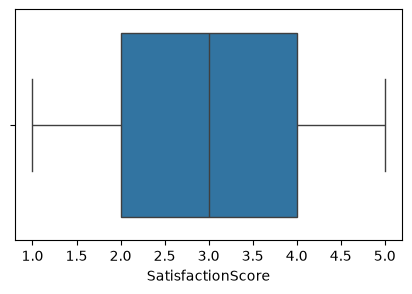

SatisfactionScore
Limite Inferior: 0
Limite Superior: 7.0
Número de ouliers: 0
Porcentagem de outliers: 0.00%


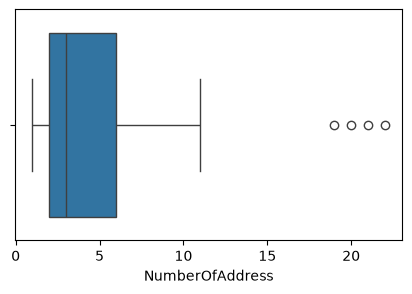

NumberOfAddress
Limite Inferior: 0
Limite Superior: 12.0
Número de ouliers: 4
Porcentagem de outliers: 0.07%


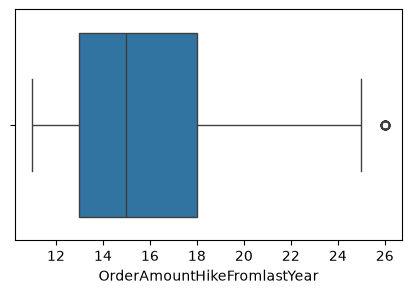

OrderAmountHikeFromlastYear
Limite Inferior: 5.5
Limite Superior: 25.5
Número de ouliers: 29
Porcentagem de outliers: 0.54%


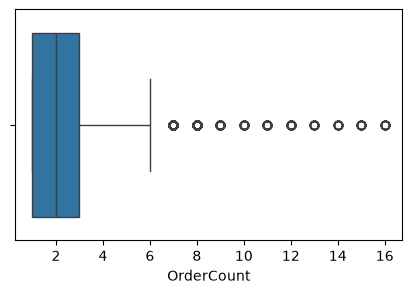

OrderCount
Limite Inferior: 0
Limite Superior: 6.0
Número de ouliers: 632
Porcentagem de outliers: 11.76%


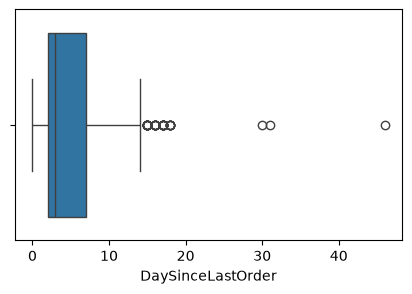

DaySinceLastOrder
Limite Inferior: 0
Limite Superior: 14.5
Número de ouliers: 45
Porcentagem de outliers: 0.84%


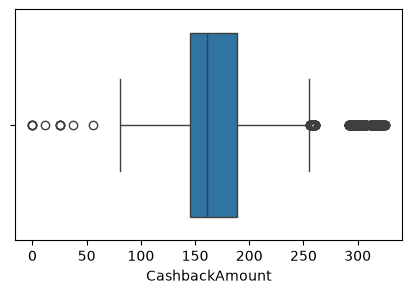

CashbackAmount
Limite Inferior: 79.0
Limite Superior: 255.0
Número de ouliers: 356
Porcentagem de outliers: 6.62%


In [24]:
df_outliers = df_drop.copy()

columns = df_outliers.columns
columns_numeric = columns.drop(['Churn','CityTier','PreferedOrderCat','PreferredLoginDevice','PreferredPaymentMode','Gender', 'MaritalStatus', 'Complain', 'CouponUsed'])

outliers_dict = {}

for c in columns_numeric:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=df_outliers, x=c)
    plt.show()
    q1 = df_outliers[c].quantile(0.25)
    q3 = df_outliers[c].quantile(0.75)
    iqr = q3 - q1

    inferior_limit = max(0,q1 - 1.5 *  iqr)
    superior_limit = q3 + 1.5 * iqr

    outliers_dict[c] = {'inferior_limit': inferior_limit, 'superior_limit': superior_limit}

    df_outliers_only = df_outliers[(df_outliers[c] < inferior_limit) | (df_outliers[c] > superior_limit)]

    print(f'{c}\nLimite Inferior: {inferior_limit}\nLimite Superior: {superior_limit}')
    print(f'Número de ouliers: {len(df_outliers_only)}')
    print(f'Porcentagem de outliers: {(len(df_outliers_only) * 100 / len(df_outliers)):.2f}%')

O tratamento dos outiliers será feito pois 1 dos modelos que serão treinados neste projeto é o KNN. O KNN acaba sendo muito sensível a outliers afetando calculo da distância euclidiana do modelo. O outro modelo que será treinado é o Decision Tree, mas como ele é um modelo que não utiliza distancia euclidiana mas sim calculo de gini para sua decisões, outliers acabam sendo irrelevantes

Foi decidido que serão mantidos os outliers das colunas: HourSpendOnApp, NumberOfDeviceRegistered e OrderCount

Motivo: HourSpendOnApp e NumberOfDeviceRegistered foram mantidos pois são valores condizentes e próximas da maior concentração de dados, não afetando negativamente o calculo da distância euclidiana, já o OrderCount sera mantido pois os outliers representam aproximadamente 11% da base e estão muito distribuidos, também não distorcendo a distancia euclidiana.

Serão removidos completamente os outliers dos campos: Tenure, WarehouseToHome e NumberOfAddress

Motivo: esses outliers representam uma porcentagem muito pequena dos dados, chegando a menos de 1%, e eles estão muito distantes para ser realista substituir eles por um valor máximo.

Serão removidos parcialmete e substituidos por um valor máxima os campos DaySinceLastOrder CashbackAmount

Explicação do que será feito: os outliers mais descrepantes serão completamente removidos, e os outliers mais próximos da concentração dos dados serão ajustados para um valor que sera o limite superior

Motivo: Como a maior parte dos outliers do DaySinceLastOrder estão próximos da concentração dos dados é totalmente realista ajustar esses dados para o limite máximo, e os dados mais descrepantes iriam atrapalhar muito a distância euclidiana então serão removidos. No  caso do CashbackAmount os outiliers representavam aproximadamente 6% dos dados da base, então para tentar diminuir a perda dos dados eu fiz uma análise (na celula abaixo) para identificar em quanto eu poderia diminuir esta perda apenas excluindo os outiliers mais descrepantes, e o resultado uma perda de aproximadamente 5%, para os outliers mais próximos da concentração foram substituidos os valores para o limite superior

A coluna SatisfactionScore não houveram outliers, muito provavelmente por ser um coluna mais restrita (1-5)

Quantos registros serão perdidos excluindo apenas os outliers mais descrepantes da coluna CashbackAmount

In [25]:
outliers_to_drop_count = df_outliers.loc[df_outliers['CashbackAmount'] > 265, 'CashbackAmount'].count()
print(f'Numero de outliers: {outliers_to_drop_count}')
print(f'Porcentagem de outliers: {outliers_to_drop_count * 100 / len(df_outliers):.2f}%')

Numero de outliers: 283
Porcentagem de outliers: 5.27%


Remoção completa dos outliers das colunas Tenure, WarehouseToHome e NumberOfAddress

In [26]:
columns_outliers_drop_completely = ['Tenure', 'WarehouseToHome', 'NumberOfAddress']
columns_outliers_drop_adjust_partially = ['DaySinceLastOrder', 'CashbackAmount']

for c in columns_outliers_drop_completely:
    df_outliers = df_outliers[~(df_outliers[c] > outliers_dict[c]['superior_limit'])]

Remoção parcial das colunas DaySinceLastOrder e CashbackAmount

In [27]:
df_outliers = df_outliers[~(df_outliers['DaySinceLastOrder'] > 20)]
df_outliers = df_outliers[~(df_outliers['CashbackAmount'] > 265)]

Substituição dos outliers restantes pelo limite superior calculado anteriormente

In [28]:
superior_limit_days = outliers_dict['DaySinceLastOrder']['superior_limit']
superior_limit_cashback = outliers_dict['CashbackAmount']['superior_limit']

df_outliers.loc[df_outliers['DaySinceLastOrder'] > superior_limit_days, 'DaySinceLastOrder'] = superior_limit_days
df_outliers.loc[df_outliers['CashbackAmount'] > superior_limit_cashback, 'CashbackAmount'] = superior_limit_cashback

# Feature Engineering

verifica se nenhum campo ficou com algum valor nulo antes de criar a coluna

In [29]:
df_feature_engineering = df_outliers.copy()
df_feature_engineering.isna().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Cria a coluna cashback_por_pedido calculando o cashback total divido pelo numero de pedidos

In [30]:
df_feature_engineering['cashback_por_pedido'] = df_feature_engineering['CashbackAmount'] / df_feature_engineering['OrderCount']

# Pré Treino

### Codificação das colunas categoricas

Como as colunas categoricas sem codificação que estão na base são todas nominais, será aplicada a técnica OneHotEnconding pela função getdummies()

Motivo: como são categorias nominais ou seja, não possuem uma ordem de grandeza (menor e maior) utilizar uma numeração iria distorcer a forma que o modelo enxerga as categorias, fazendo ele acreditar que uma categoria é maior que a outra, mas com o OneHotEnconding esse problema é resolvido pois ele cria uma coluna binária (0/1 - falso/verdadeiro) para cada categoria, assim possibilitando o modelo identificar a categoria do registro mas sem ter a distorção de que uma é maior que a outra

In [31]:
df_encoder = df_feature_engineering.copy()

columns_categorical = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

df_encoded = pd.get_dummies(data=df_encoder, columns=columns_categorical, drop_first=True, dtype=int)

df_encoded.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.000000,3,2,9,1,11.0,...,1,0,0,0,0,1,0,0,0,1
1,1,9.0,1,8.0,3.000000,4,3,7,1,15.0,...,0,0,1,1,0,0,1,0,0,1
2,1,9.0,1,30.0,2.000000,4,3,6,1,14.0,...,1,0,0,1,0,0,1,0,0,1
3,1,0.0,3,15.0,2.000000,4,5,8,0,23.0,...,1,0,0,1,0,1,0,0,0,1
4,1,0.0,1,12.0,2.931535,3,5,3,0,11.0,...,0,0,0,1,0,0,1,0,0,1


### Divisão dos dados de treino e teste

Os dados foram divididos entre conjunto de treino e teste, com uma divisão de 80/20 (80% treino, 20% teste), também se tomou o cuidado para que tanto o conjunto de treino quanto o de teste tenham registros com a mesma quantidade de classes (churn 0 e 1)

In [32]:
df_train_test = df_encoded.copy()

y = df_train_test['Churn']
X = df_train_test.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

### Balanceamento das classes

Para resolver o problema do desbalanceamento das classes foi utilizado a técnica smote, que consiste em criar novos registros com a classe minoritária até que a quantidade de registros de cada classe sejam iguais

Detalhe: Para evitar avaliações incorretas sobre o modelo, o smote foi aplicado apenas no conjunto de treino, pois o conjunto de teste deve se o mais próximo do mundo real, por isso é importante manter o desbalanceamento no conjunto de teste, caso contrário o modelo apresentaria um resultado muito diferente do que teria com dados reais

In [33]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

### Escalonamento

Para o escalonamento, foi criado um conjunto de dados específicos para o modelo KNN, pois como o KNN é um modelo que utiliza distâncias euclidianas para decidir quais vizinhos estão mais próximos dele para contabilizar os votos e ter um resultado, ele acaba sendo muito sensivel a dados numéricos quantitativos, por exemplo, o KNN poderia achar que CashbackAmount é mais imporante do que NumberOfAddress no calculo

Já o modelo Decision tree não é necessário o escalonamento pois ele não utiliza curvas euclidianas para suas decisões, ele cria vários cortes nos dados baseados em condicionais e verifica o nível de pureza (Gini) da divisão dos dados gerado por aquele corte para construir sua árvore de decisão até chegar ao resultado, por isso CashbackAmount ter numeros maiores que NumberOfAddress não faz diferença

In [34]:
X_train_knn = X_train_smote.copy()
X_test_knn = X_test.copy()

columns_to_scale = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'cashback_por_pedido']

scaler = StandardScaler()

X_train_knn[columns_to_scale] = scaler.fit_transform(X_train_knn[columns_to_scale])
X_test_knn[columns_to_scale] = scaler.transform(X_test_knn[columns_to_scale])

# Modelagem e Validação

### Treino e teste do modelo KNN

Resultado do modelo com K = 3
Accuracy score: 0.86
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       832
           1       0.58      0.89      0.70       184

    accuracy                           0.86      1016
   macro avg       0.78      0.87      0.81      1016
weighted avg       0.90      0.86      0.87      1016

Matriz de confusão


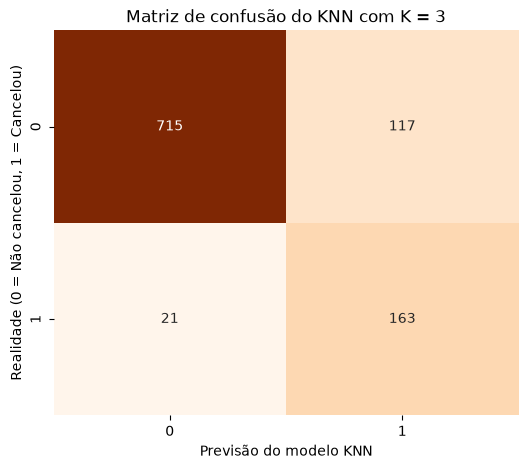

Resultado do modelo com K = 5
Accuracy score: 0.84
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       832
           1       0.54      0.90      0.67       184

    accuracy                           0.84      1016
   macro avg       0.76      0.86      0.79      1016
weighted avg       0.89      0.84      0.86      1016

Matriz de confusão


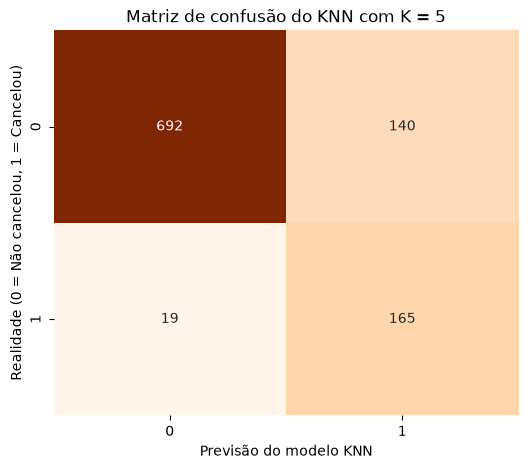

Resultado do modelo com K = 7
Accuracy score: 0.82
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       832
           1       0.50      0.86      0.63       184

    accuracy                           0.82      1016
   macro avg       0.73      0.83      0.75      1016
weighted avg       0.88      0.82      0.83      1016

Matriz de confusão


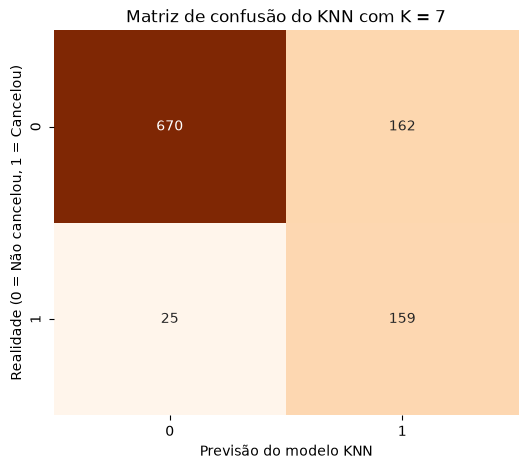

Resultado do modelo com K = 9
Accuracy score: 0.79
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       832
           1       0.46      0.89      0.61       184

    accuracy                           0.79      1016
   macro avg       0.72      0.83      0.73      1016
weighted avg       0.88      0.79      0.81      1016

Matriz de confusão


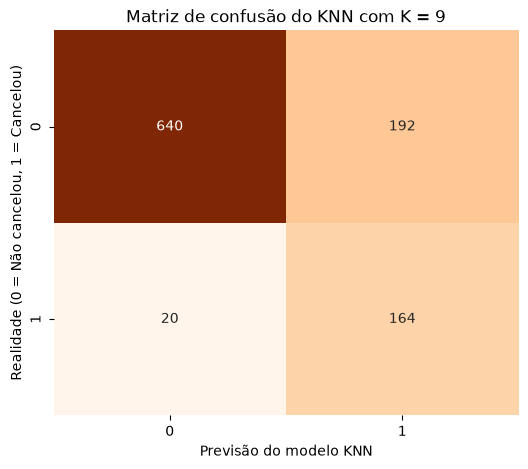

In [78]:
k_list = [3,5,7,9]
knn_predictions = {}

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_knn, y_train_smote)
    knn_prediction = knn.predict(X_test_knn)
    knn_predictions[k] = knn_prediction

for r in knn_predictions:
    print(f'Resultado do modelo com K = {r}')
    print(f'Accuracy score: {accuracy_score(y_test, knn_predictions[r]):.2f}')
    print(classification_report(y_test, knn_predictions[r]))
    print('Matriz de confusão')
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, knn_predictions[r]), annot=True, fmt='d', cmap='Oranges', cbar=False)
    plt.title(f'Matriz de confusão do KNN com K = {r}')
    plt.ylabel('Realidade (0 = Não cancelou, 1 = Cancelou)')
    plt.xlabel('Previsão do modelo KNN')
    plt.show()



### Treino e teste do modelo Decision Tree

Resultado do modelo com max_depth = None
Accuracy score: 0.91
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       832
           1       0.73      0.79      0.76       184

    accuracy                           0.91      1016
   macro avg       0.84      0.86      0.85      1016
weighted avg       0.91      0.91      0.91      1016

Matriz de confusão


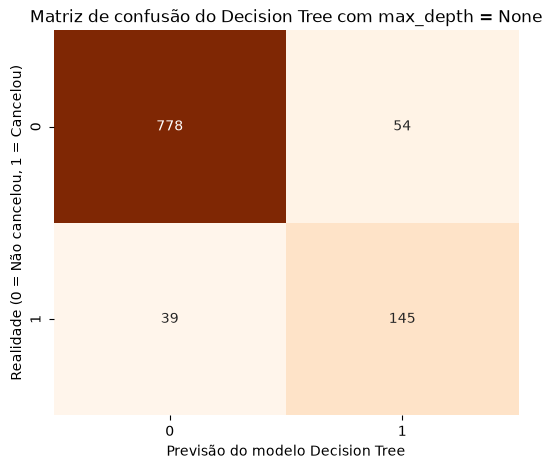

Resultado do modelo com max_depth = 3
Accuracy score: 0.81
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       832
           1       0.49      0.68      0.57       184

    accuracy                           0.81      1016
   macro avg       0.70      0.76      0.72      1016
weighted avg       0.84      0.81      0.82      1016

Matriz de confusão


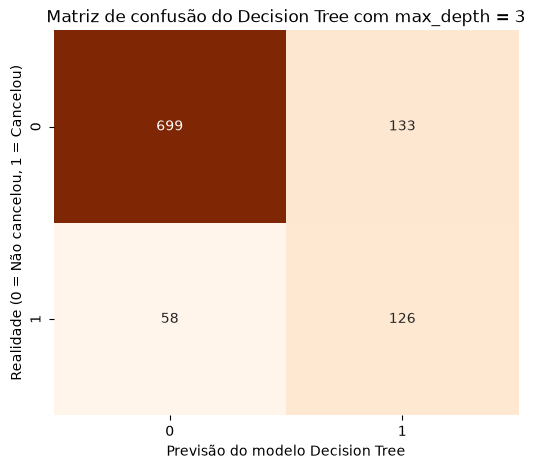

Resultado do modelo com max_depth = 5
Accuracy score: 0.78
              precision    recall  f1-score   support

           0       0.93      0.79      0.86       832
           1       0.44      0.72      0.55       184

    accuracy                           0.78      1016
   macro avg       0.68      0.76      0.70      1016
weighted avg       0.84      0.78      0.80      1016

Matriz de confusão


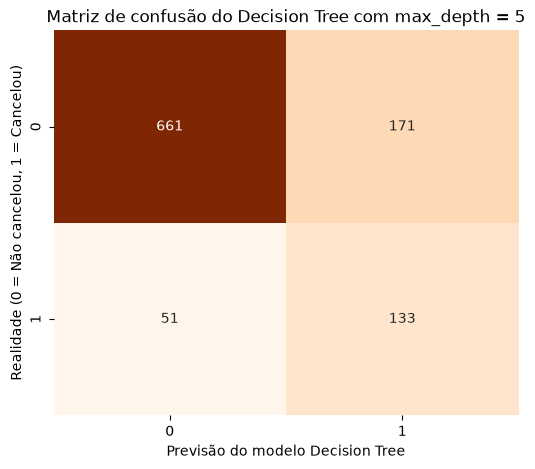

Resultado do modelo com max_depth = 7
Accuracy score: 0.82
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       832
           1       0.50      0.66      0.57       184

    accuracy                           0.82      1016
   macro avg       0.71      0.76      0.73      1016
weighted avg       0.84      0.82      0.83      1016

Matriz de confusão


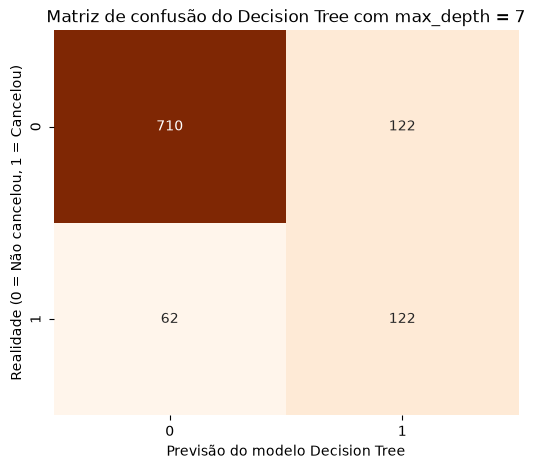

In [79]:
max_depth_list = [None, 3, 5, 7]
tree_predictions = {}

for md in max_depth_list:
    tree = DecisionTreeClassifier(max_depth=md, random_state=42, criterion='gini')
    tree.fit(X_train_smote, y_train_smote)
    tree_predictions[md] = tree.predict(X_test)

for tp in tree_predictions:
    print(f'Resultado do modelo com max_depth = {tp}')
    print(f'Accuracy score: {accuracy_score(y_test, tree_predictions[tp]):.2f}')
    print(classification_report(y_test, tree_predictions[tp]))
    print('Matriz de confusão')
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, tree_predictions[tp]), annot=True, fmt='d', cmap='Oranges', cbar=False)
    plt.title(f'Matriz de confusão do Decision Tree com max_depth = {tp}')
    plt.ylabel('Realidade (0 = Não cancelou, 1 = Cancelou)')
    plt.xlabel('Previsão do modelo Decision Tree')
    plt.show()